<a href="https://colab.research.google.com/github/AbdulkaderKharrat/AbdulkaderKharrat/blob/main/UAEUSEDCARS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/uae_used_cars_10k (1).csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/uae_used_cars_10k (1).csv'

In [ ]:
df.describe()

NameError: name 'df' is not defined

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Price,0
Mileage,0
Body Type,0
Cylinders,105
Transmission,0
Fuel Type,0
Color,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Make          10000 non-null  object
 1   Model         10000 non-null  object
 2   Year          10000 non-null  int64 
 3   Price         10000 non-null  int64 
 4   Mileage       10000 non-null  int64 
 5   Body Type     10000 non-null  object
 6   Cylinders     9895 non-null   object
 7   Transmission  10000 non-null  object
 8   Fuel Type     10000 non-null  object
 9   Color         10000 non-null  object
 10  Location      10000 non-null  object
 11  Description   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB


In [ ]:
numerical_df = df.select_dtypes(include=['number'])
numerical_df.head()

,Year,Price,Mileage
0,2016,47819,156500
1,2013,61250,169543
2,2023,31861,221583
3,2016,110322,69754
4,2020,139994,71399


In [ ]:
categorical_df = df.select_dtypes(include=['object'])
categorical_df.head()

,Make,Model,Body Type,Cylinders,Transmission,Fuel Type,Color,Location,Description
0,toyota,camry,Sedan,4,Automatic Transmission,Gasoline,Black,Dubai,"2016 toyota camry with Rear camera, Leather se..."
1,kia,sorento,SUV,4,Automatic Transmission,Gasoline,Grey,Abu Dhabi,"2013 kia sorento with Sunroof, Adaptive cruise..."
2,mini,cooper,Soft Top Convertible,4,Automatic Transmission,Gasoline,Grey,Dubai,"2023 mini cooper with Adaptive cruise control,..."
3,nissan,altima,Sedan,4,Automatic Transmission,Gasoline,Red,Dubai,"2016 nissan altima with Rear camera, Adaptive ..."
4,toyota,land-cruiser-76-series,Pick Up Truck,4,Manual Transmission,Gasoline,White,Dubai,2020 toyota land-cruiser-76-series with Adapti...


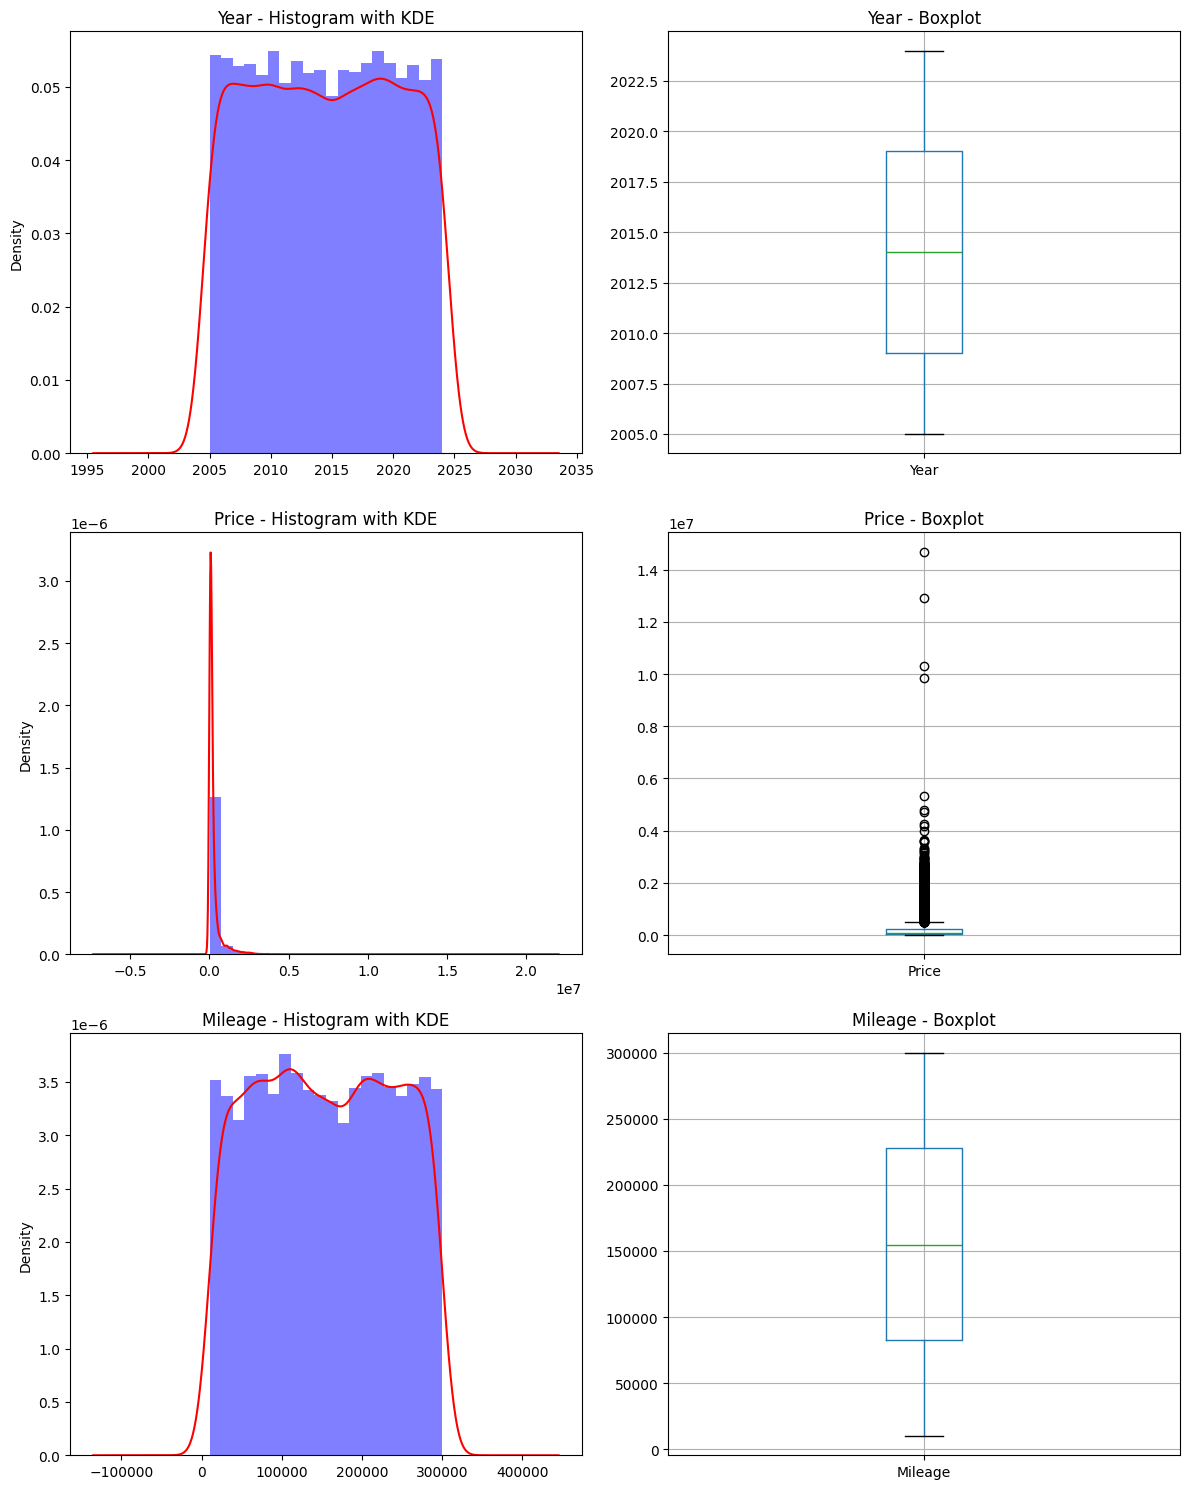

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'numerical_df' from your previous code is the DataFrame
# containing numerical features.  Replace with your actual DataFrame if different.
numerical_features = numerical_df

# Plotting Histogram with KDE and Boxplot for each numerical feature
fig, axes = plt.subplots(len(numerical_features.columns), 2, figsize=(12, 5 * len(numerical_features.columns)))
for i, col in enumerate(numerical_features.columns):
    # Histogram with KDE
    numerical_features[col].plot(kind='hist', density=True, ax=axes[i, 0], bins=20, alpha=0.5, color='blue')
    numerical_features[col].plot(kind='kde', ax=axes[i, 0], color='red')
    axes[i, 0].set_title(f'{col} - Histogram with KDE')
    # Boxplot
    numerical_features.boxplot(column=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - Boxplot')
plt.tight_layout()
plt.show()


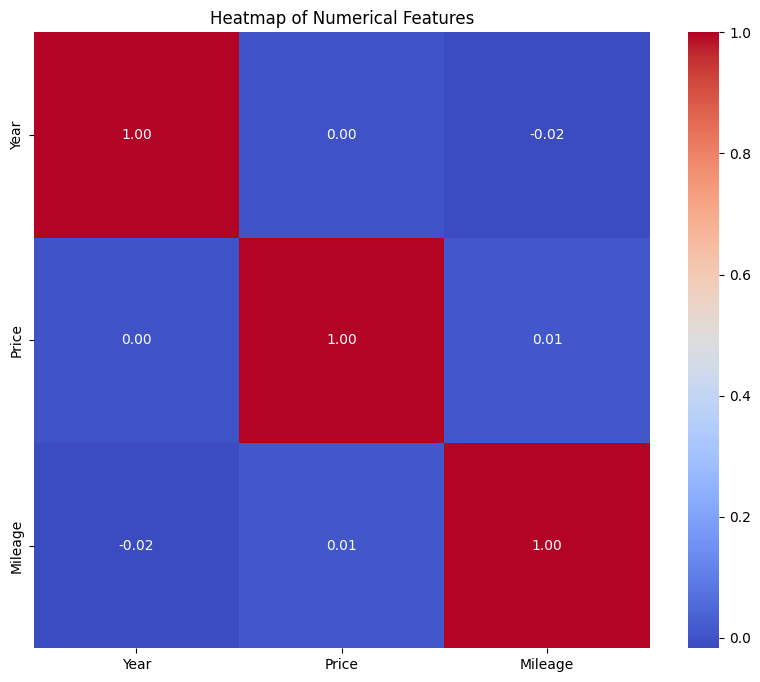

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'numerical_features' is defined as in your previous code
# If not, replace with your actual DataFrame containing numerical features

corr = numerical_features.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Heatmap of Numerical Features')
plt.show()


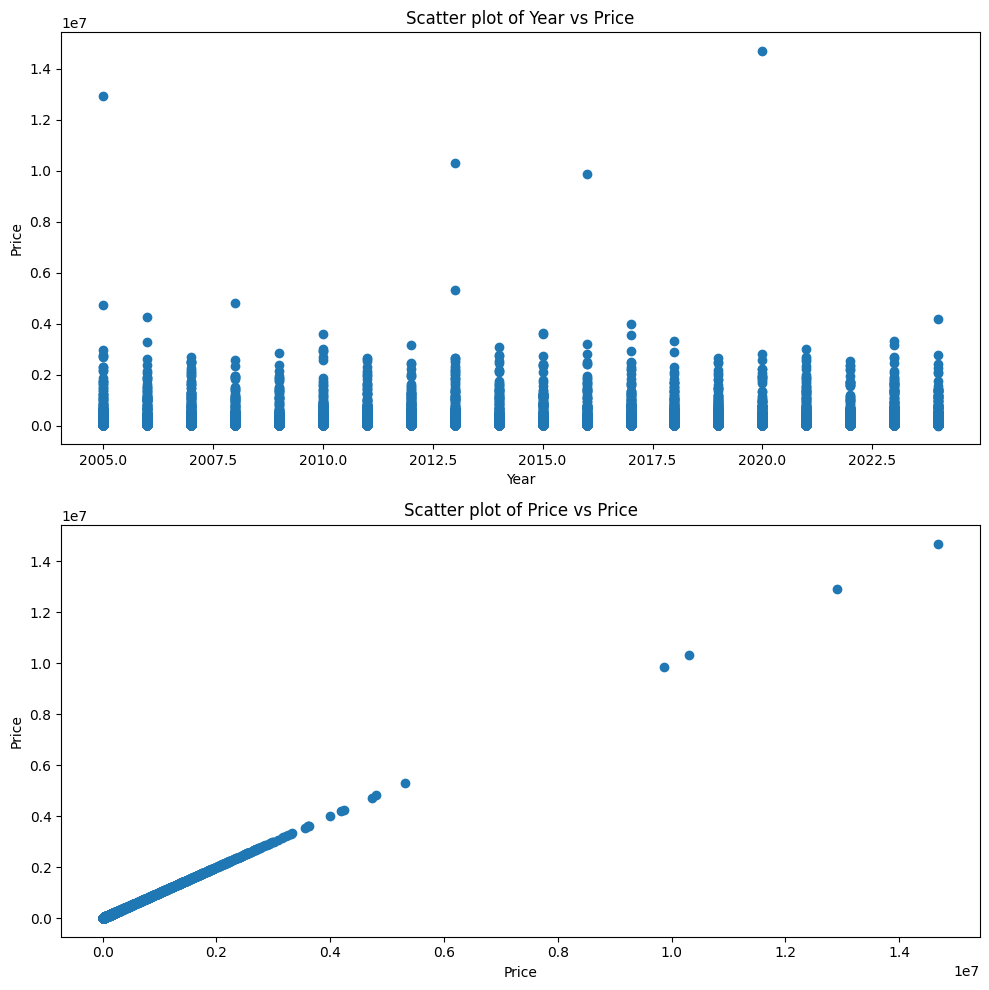

In [ ]:
# scatter

# Creating scatter plots for each feature against the price
n_features = numerical_features.shape[1] - 1  # excluding the 'price' column
fig, axs = plt.subplots(n_features, figsize=(10, n_features * 5))

for i, feature in enumerate(numerical_features.columns[:-1]):  # excluding 'price'
    axs[i].scatter(numerical_features[feature], numerical_features['Price'])
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('Price')
    axs[i].set_title(f'Scatter plot of {feature} vs Price')

plt.tight_layout()
plt.show()

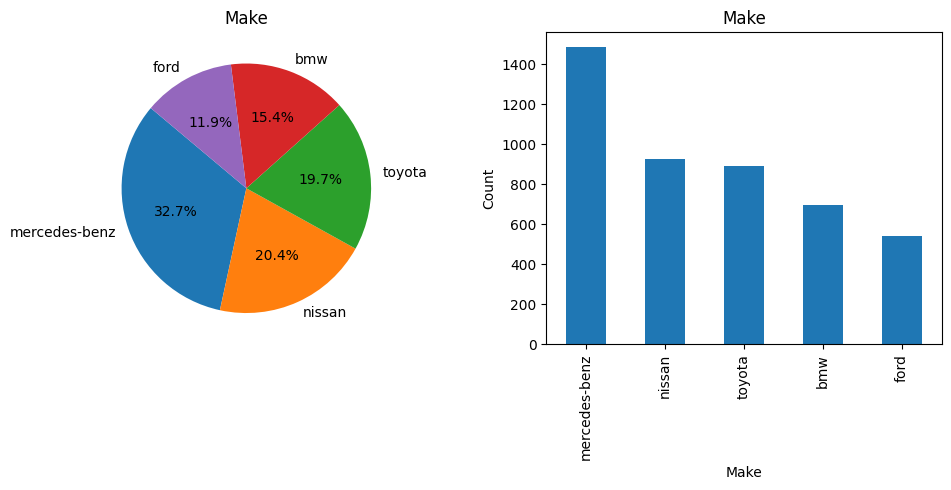

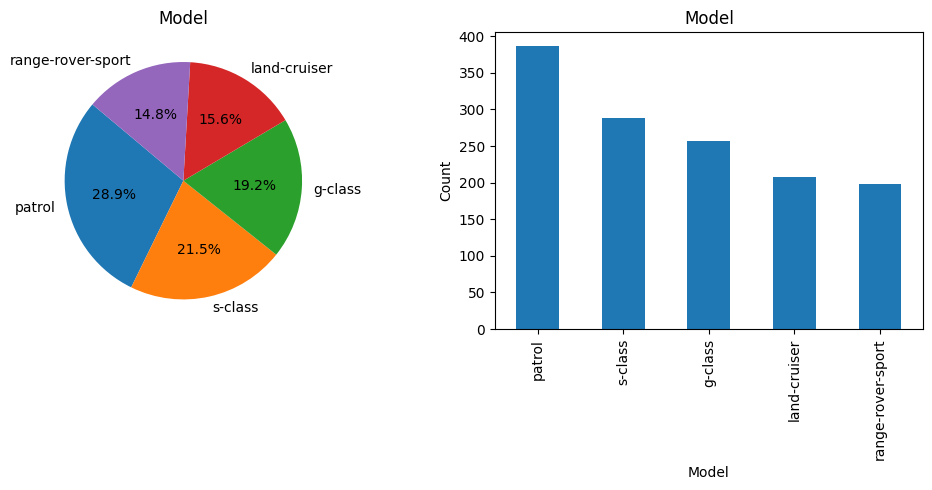

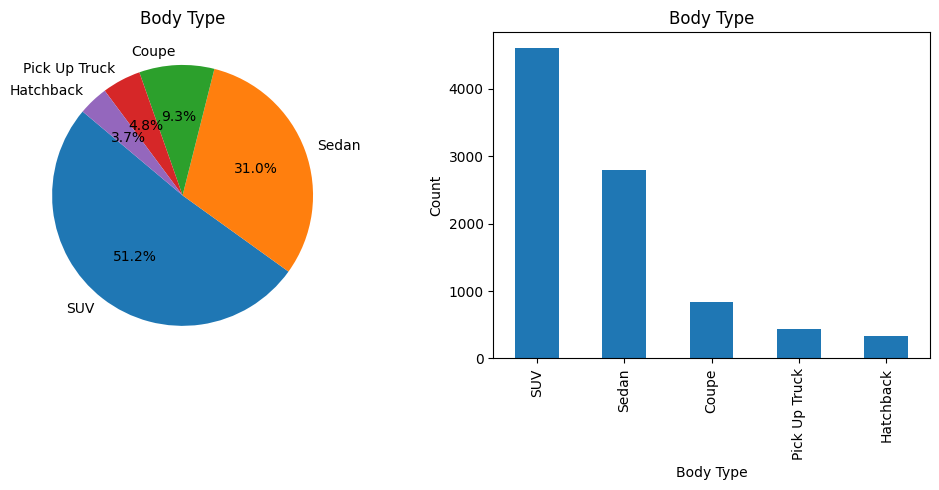

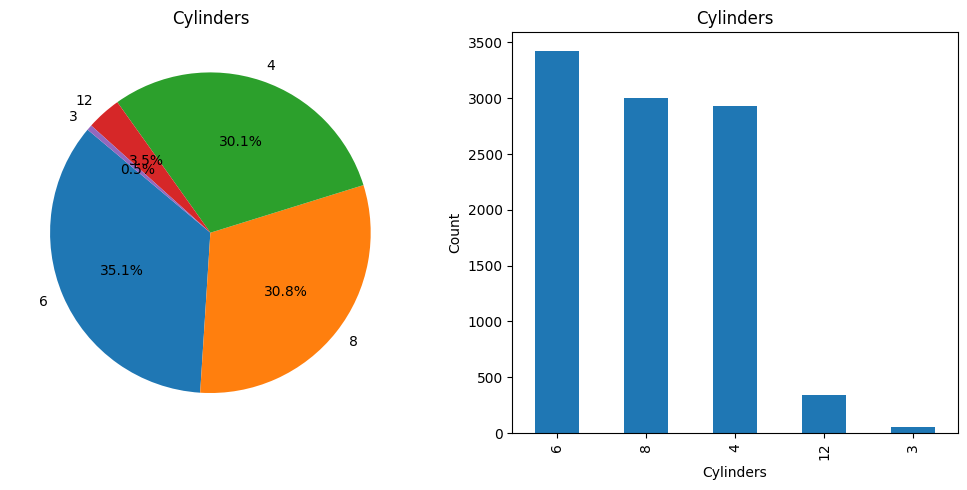

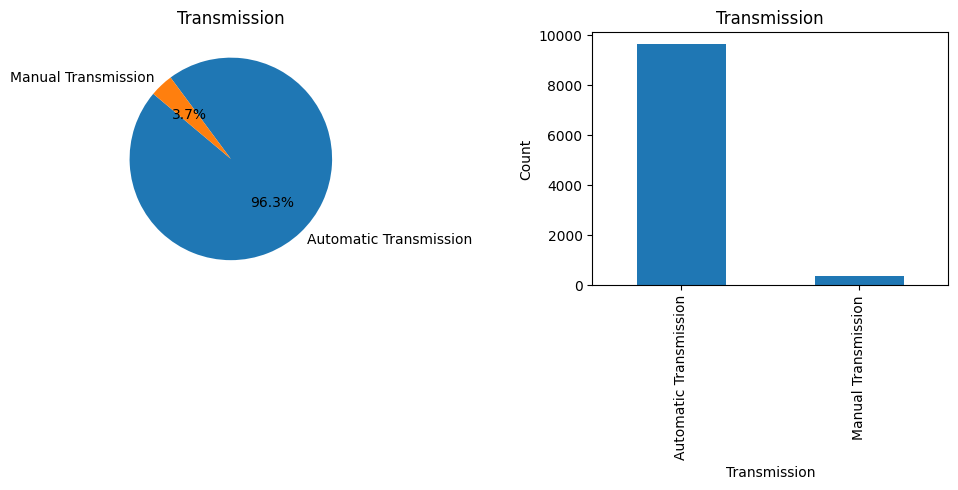

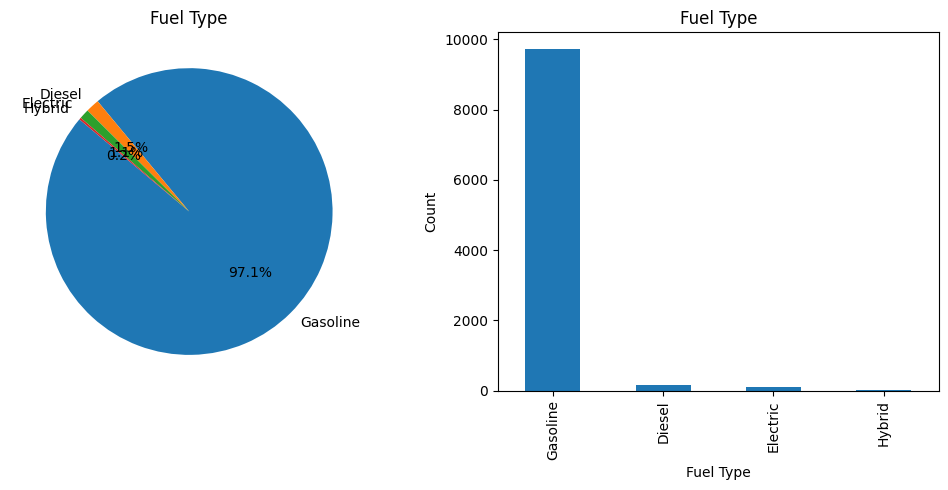

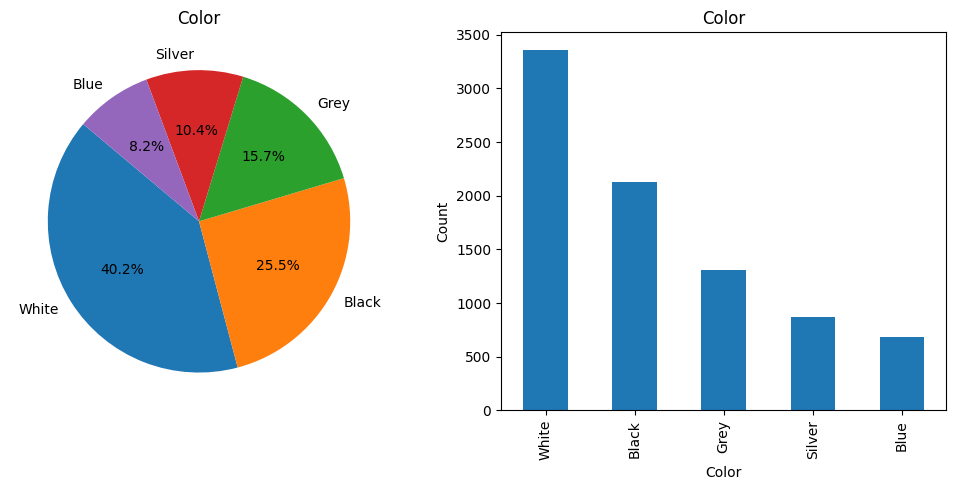

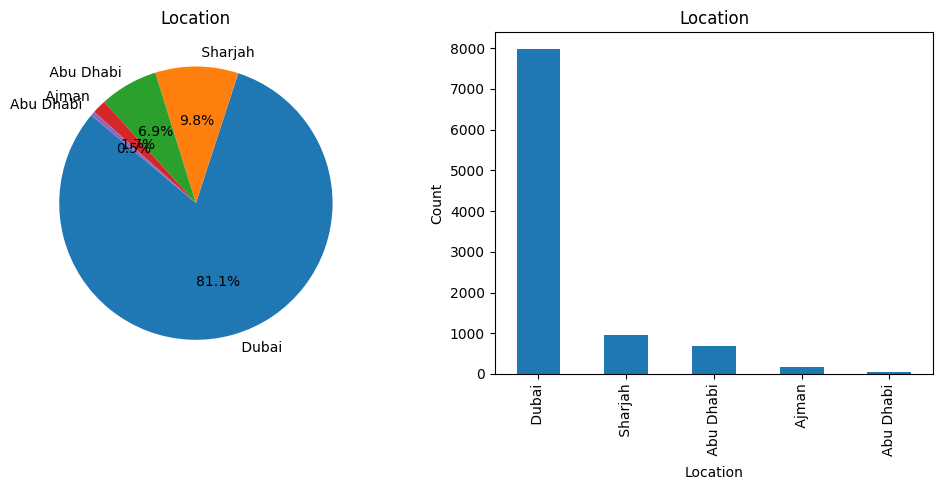

<ipython-input-18-5102c401f04d>:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


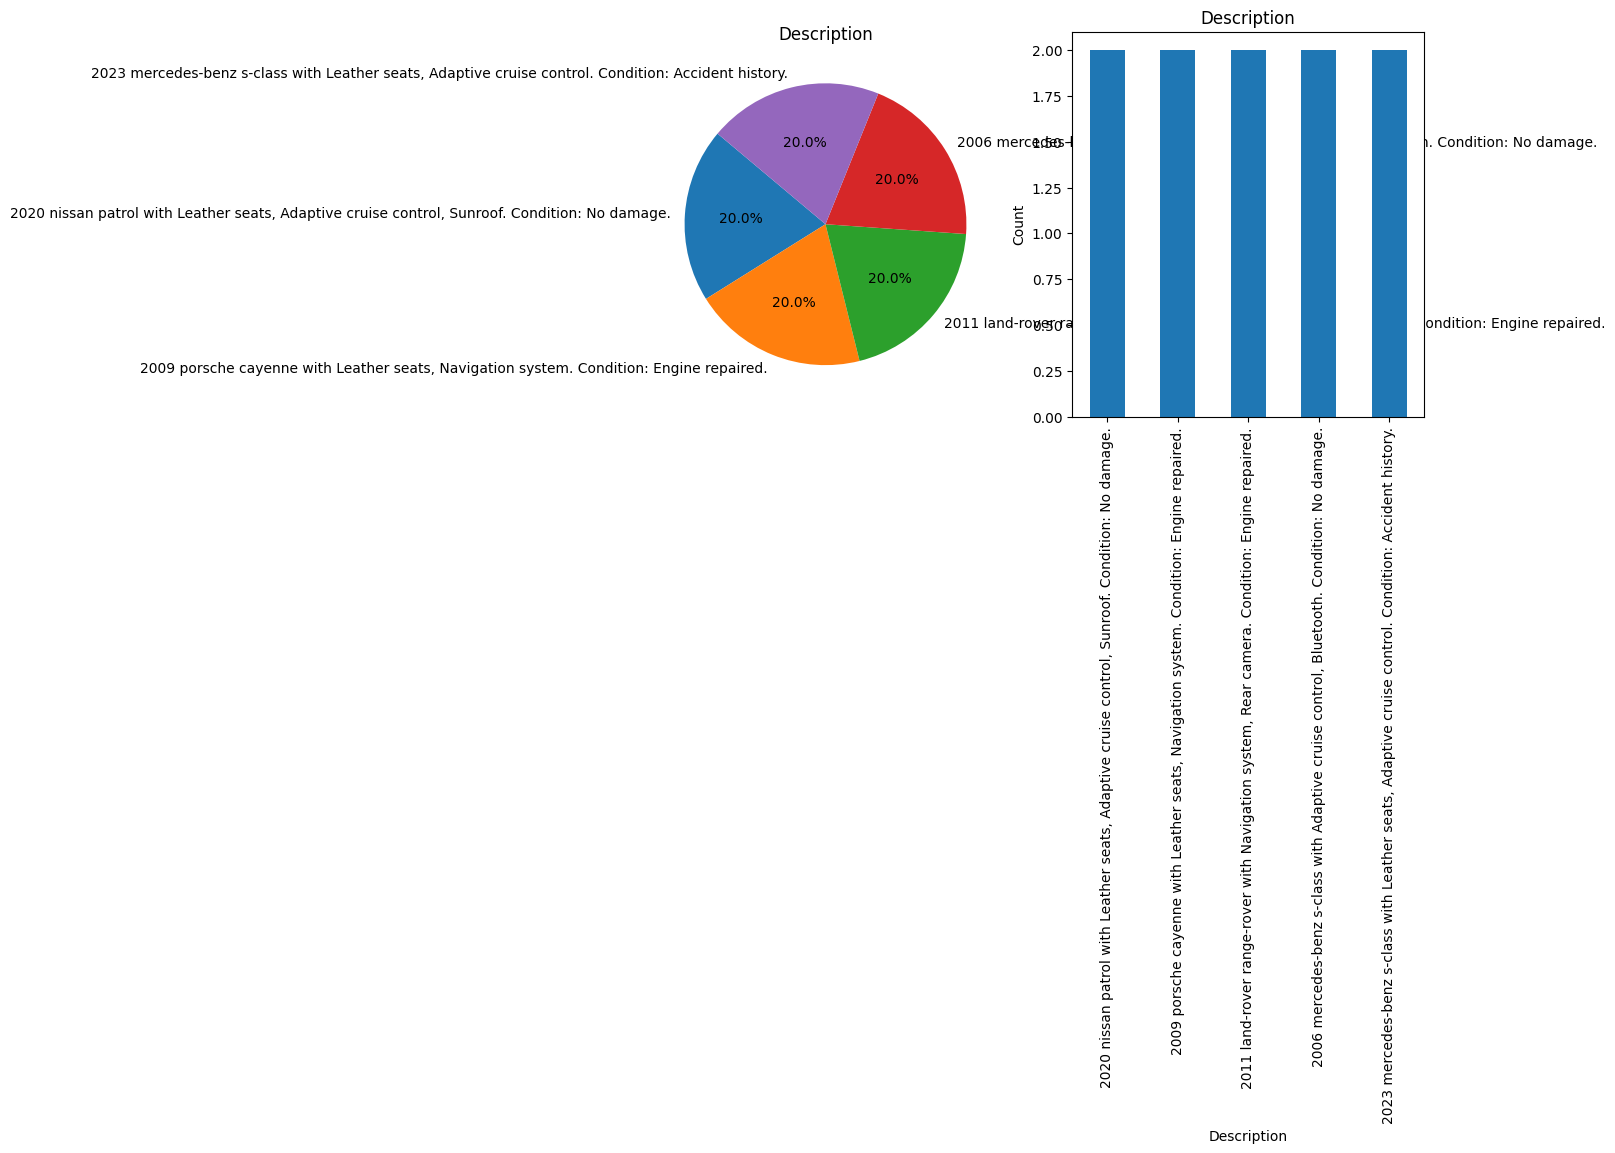

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = df.select_dtypes(include=['object'])

for i in categorical_features.columns:
  counts = categorical_features[i].value_counts().head(5) # Show only top 10
  # Plotting
  fig, axes = plt.subplots(1, 2, figsize=(12, 6))
  # Pie chart
  axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
  axes[0].set_title(i)
  # Bar chart
  counts.plot(kind='bar', ax=axes[1])
  axes[1].set_title(i)
  axes[1].set_ylabel('Count')
  axes[1].set_xlabel(i)
  plt.tight_layout()
  plt.show()
